# Un imán flotando midió 32 femtoteslas — pero solo en una nota

**32 femtoteslas por raíz de hercio.** Mil millones de veces por debajo del campo magnético de la Tierra —ese "por raíz de hercio" es la unidad en que se mide el ruido, no el rango donde el sensor funciona—, y lo consiguió un imán que flota en el aire, sin frío, sin vacío, en un laboratorio a temperatura ambiente. Igual de fino que un SQUID criogénico. Con una trampa: ese número solo se sostiene en una rebanada de frecuencia de 0,04 Hz.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Ji et al. (2026), *Levitated sensor for magnetometry in ambient environment*, **Science** · [DOI: 10.1126/science.adx1707](https://doi.org/10.1126/science.adx1707)
**Datos:** [Zenodo 10.5281/zenodo.19631231](https://doi.org/10.5281/zenodo.19631231) (CC-BY-4.0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-07-magnetometro-levitado/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/IT2pe2D4Edc)

## Qué construyeron

Un imán diminuto que **levita solo**, sostenido por materiales diamagnéticos —los que el campo magnético empuja en vez de atraer—, sin nada que lo toque. Cuando pasa un campo magnético externo, el imán gira un poquito. Un láser lee ese giro.

La gracia está en lo que *no* necesita. Los dos magnetómetros más finos del mundo —los SQUID, anillos superconductores que hay que enfriar casi hasta el cero absoluto, y los atómicos— piden helio líquido o celdas de vapor calientes y blindaje. Y ese «por raíz de hercio» del titular no es adorno: mide ruido por unidad de ancho de banda, y de ahí sale toda la historia de este notebook. Este funciona sobre una mesa, al aire, dentro del campo magnético de la Tierra.

Los autores depositaron en Zenodo el código MATLAB y los datos crudos de sus figuras. Vamos a abrirlos y a mirar exactamente qué tan fino es, y dónde.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FREQ_RESONANCIA   = 304.84    # Hz — donde el espectro depositado toca su mínimo
UMBRAL_FT         = 100       # fT/√Hz — umbral para medir el ancho útil
FUENTE = 'Fuente: Ji et al. (2026), Science | Datos: Zenodo 10.5281/zenodo.19631231'
COLOR_DATOS       = '#2563EB'
COLOR_ALERTA      = '#DC2626'
COLOR_SECUNDARIO  = '#059669'
COLOR_REFERENCIA  = '#D97706'
COLOR_CONTEXTO    = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def es(x, dec=0):
    """Formato numérico español: miles con punto, decimales con coma."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-07-magnetometro-levitado'

# Estilo CaM (local -> GitHub raw como fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

ARCHIVOS = ['sensibilidad_banda_completa.csv', 'presupuesto_ruido_zoom.csv',
            'espectros_repeticiones.csv', 'curva_respuesta_medida.csv',
            'respuesta_campo_guia.csv']
for nombre in ARCHIVOS:
    destino = f'datos/{nombre}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', destino)

banda      = pd.read_csv('datos/sensibilidad_banda_completa.csv')   # 1-1200 Hz, envolvente por ventana de 0,5 Hz
zoom       = pd.read_csv('datos/presupuesto_ruido_zoom.csv').sort_values('frecuencia_hz').reset_index(drop=True)
repes      = pd.read_csv('datos/espectros_repeticiones.csv')        # 5 espectros + media + banda
respuesta  = pd.read_csv('datos/curva_respuesta_medida.csv')        # 13 puntos de respuesta
campo_guia = pd.read_csv('datos/respuesta_campo_guia.csv')          # 6 puntos, dos campos guia

# El mejor punto del espectro depositado
i_min = zoom['sensibilidad_total_ft'].idxmin()
SENS_MIN  = zoom.loc[i_min, 'sensibilidad_total_ft']
FREQ_MIN  = zoom.loc[i_min, 'frecuencia_hz']

# Media de las 5 repeticiones en esa misma frecuencia
j = (repes['frecuencia_hz'] - FREQ_MIN).abs().idxmin()
MEDIA_5   = repes.loc[j, 'sensibilidad_media_ft']
INCERT_5  = repes.loc[j, 'incertidumbre_ft']

# Ancho útil: puntos contiguos bajo el umbral ALREDEDOR DEL RÉCORD (resolución 0,01 Hz).
# Ojo: la racha más larga del archivo NO es la del récord — hay que crecer desde i_min.
bajo = (zoom['sensibilidad_total_ft'] < UMBRAL_FT).values
ini = fin = i_min
while ini - 1 >= 0 and bajo[ini - 1]:
    ini -= 1
while fin + 1 < len(bajo) and bajo[fin + 1]:
    fin += 1
N_PUNTOS_PICO = fin - ini + 1
ANCHO_UTIL = N_PUNTOS_PICO * 0.01
F_INI, F_FIN = zoom.loc[ini, 'frecuencia_hz'], zoom.loc[fin, 'frecuencia_hz']
# Y cuantos puntos bajan del umbral en TODO el barrido fino, contiguos o no
PUNTOS_BAJO_TOTAL = int(bajo.sum())
GRUPOS_BAJO = int((np.diff(np.concatenate(([0], bajo.astype(int), [0]))) == 1).sum())

SENS_1HZ = banda['sensibilidad_min_ft'].iloc[0]
FREQ_1HZ = banda['frecuencia_hz'].iloc[0]
RATIO    = SENS_1HZ / SENS_MIN

print(f'Espectro completo: {len(banda)} ventanas entre {es(banda.frecuencia_hz.min(), 2)} y {es(banda.frecuencia_hz.max())} Hz')
print(f'Mejor sensibilidad: {es(SENS_MIN, 2)} fT/√Hz a {es(FREQ_MIN, 2)} Hz')
print(f'Media de 5 repeticiones ahí mismo: {es(MEDIA_5, 2)} +/- {es(INCERT_5, 2)} fT/√Hz')
print(f'  -> el valor del paper (32) cae dentro de [{es(MEDIA_5-INCERT_5, 2)}, {es(MEDIA_5+INCERT_5, 2)}]')
print(f'Pico contiguo bajo {UMBRAL_FT} fT/√Hz alrededor del récord: {es(ANCHO_UTIL, 2)} Hz '
      f'({N_PUNTOS_PICO} puntos, {es(F_INI, 2)}-{es(F_FIN, 2)} Hz)')
print(f'En todo el barrido fino: {PUNTOS_BAJO_TOTAL} puntos bajo el umbral, en {GRUPOS_BAJO} grupos separados')
print(f'Puntos por debajo de 40 fT/√Hz: {(zoom.sensibilidad_total_ft < 40).sum()}')
print(f'A {es(FREQ_1HZ, 2)} Hz: {es(SENS_1HZ)} fT/√Hz  -> {es(RATIO)} veces peor que en resonancia')

Espectro completo: 2399 ventanas entre 1,25 y 1.200 Hz
Mejor sensibilidad: 32,94 fT/√Hz a 304,84 Hz
Media de 5 repeticiones ahí mismo: 30,31 +/- 2,43 fT/√Hz
  -> el valor del paper (32) cae dentro de [27,89, 32,74]
Pico contiguo bajo 100 fT/√Hz alrededor del récord: 0,04 Hz (4 puntos, 304,82-304,85 Hz)
En todo el barrido fino: 21 puntos bajo el umbral, en 8 grupos separados
Puntos por debajo de 40 fT/√Hz: 1
A 1,25 Hz: 471.559 fT/√Hz  -> 14.317 veces peor que en resonancia


## Aquí está.

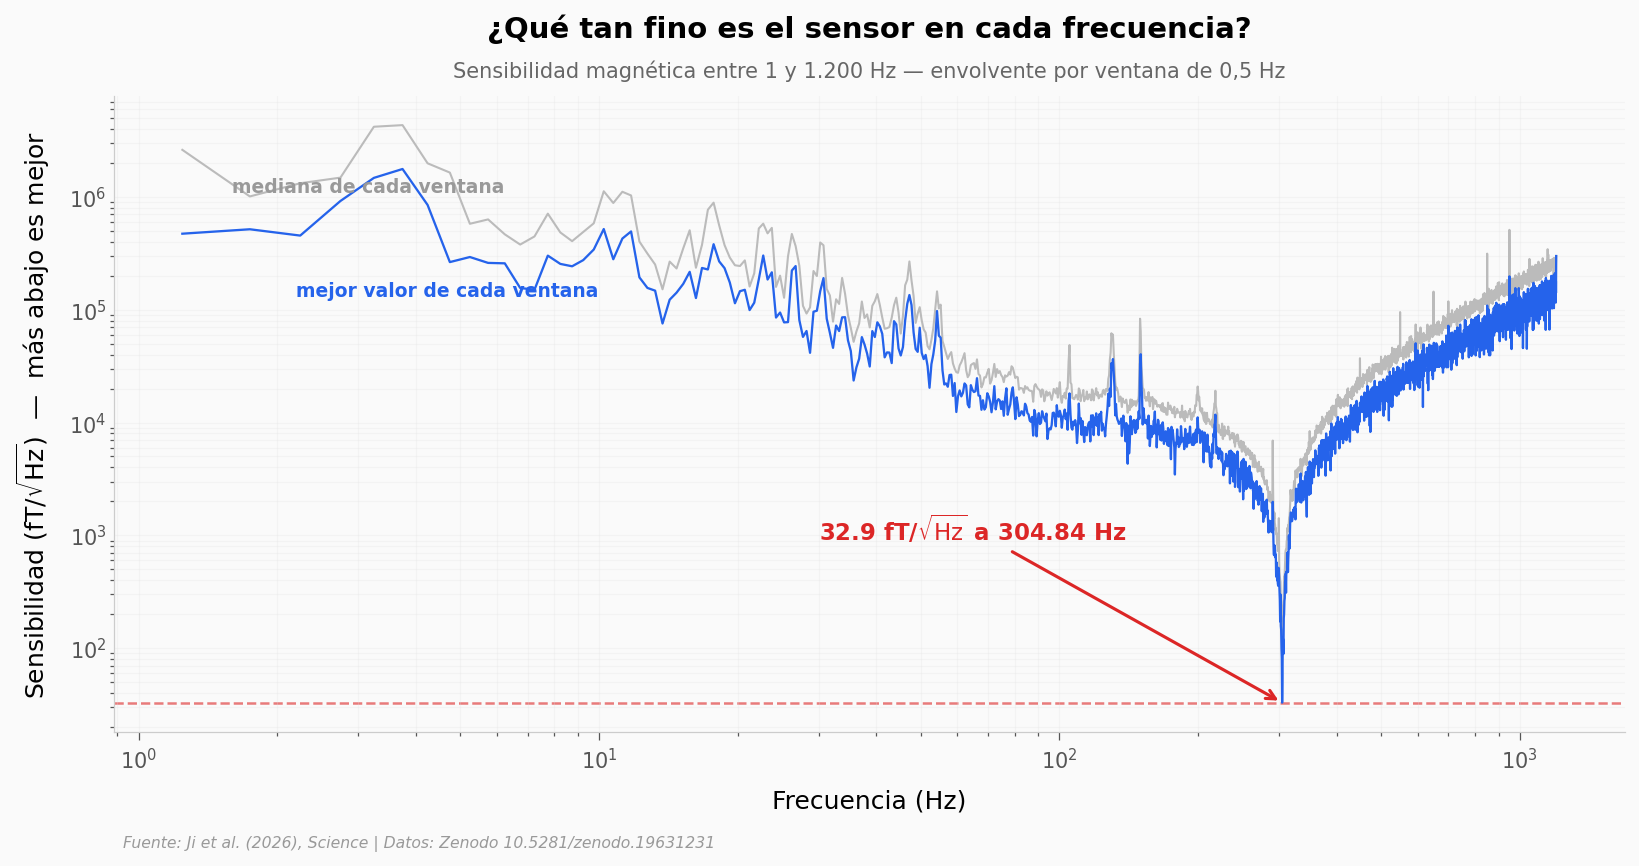

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(banda['frecuencia_hz'], banda['sensibilidad_mediana_ft'],
        color=COLOR_CONTEXTO, linewidth=1.0, zorder=2)
ax.plot(banda['frecuencia_hz'], banda['sensibilidad_min_ft'],
        color=COLOR_DATOS, linewidth=1.1, zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')

ax.axhline(y=SENS_MIN, color=COLOR_ALERTA, linewidth=1.2, linestyle='--', alpha=0.6, zorder=1)
ax.annotate(f'{SENS_MIN:.1f} fT/$\\sqrt{{\\mathrm{{Hz}}}}$ a {FREQ_MIN:.2f} Hz',
            xy=(FREQ_MIN, SENS_MIN), xytext=(30, 900),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.text(1.6, 1.1e6, 'mediana de cada ventana', fontsize=9,
        color='#999999', fontweight='bold')
ax.text(2.2, 1.3e5, 'mejor valor de cada ventana', fontsize=9,
        color=COLOR_DATOS, fontweight='bold')

ax.set_title('¿Qué tan fino es el sensor en cada frecuencia?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Sensibilidad magnética entre 1 y 1.200 Hz — envolvente por ventana de 0,5 Hz',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Sensibilidad (fT/$\\sqrt{\\mathrm{Hz}}$)  —  más abajo es mejor')
ax.grid(True, which='both', axis='both', alpha=0.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/banda_completa.png', dpi=200, bbox_inches='tight')
plt.show()

## Un pozo, no una meseta

La mitad central de la curva vive entre 10.000 y 85.000 femtoteslas, con una mediana de 36.783. Y de repente, en 304,84 Hz, cae hasta 32,9: tres órdenes de magnitud por debajo de la mediana, en una sola frecuencia.

Ese pozo es la resonancia mecánica del imán: la frecuencia a la que el imán oscila por sí solo, donde un empujón magnético mínimo produce un giro grande. A 1,25 Hz —el extremo bajo del registro— el mismo sensor mide 471.559 fT/√Hz: **14.317 veces peor**.

El titular del paper es cierto y el pozo es real. Lo que la curva agrega es *dónde* vive ese titular.

## Acerquémonos al pozo

Los autores repitieron la medición cinco veces, punto a punto cada 0,01 Hz. Bajemos al fondo del pozo.

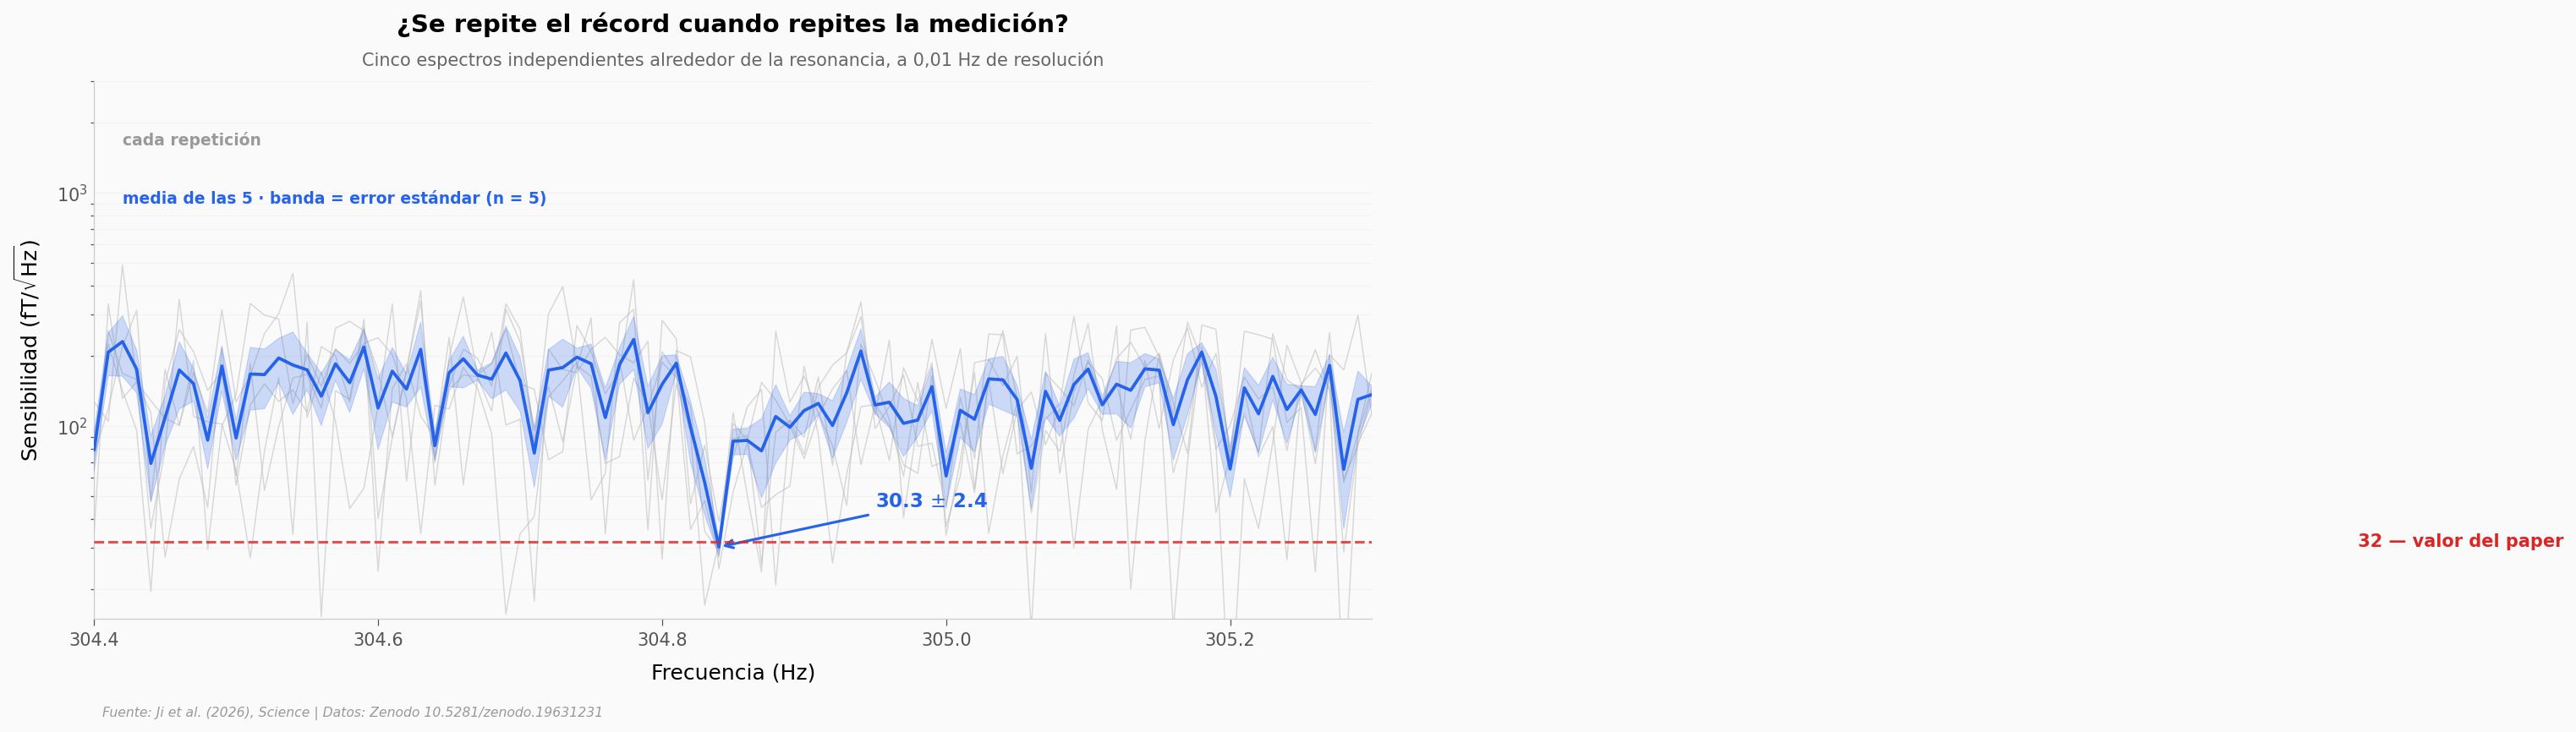

Media de 5 repeticiones a 304,84 Hz: 30,31 +/- 2,43 fT/√Hz
Rango de las 5: 24,49 - 38,82 fT/√Hz


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Las 5 repeticiones individuales, de fondo
for k in range(1, 6):
    ax.plot(repes['frecuencia_hz'], repes[f'repeticion_{k}_ft'],
            color=COLOR_CONTEXTO, linewidth=0.7, alpha=0.55, zorder=2)

ax.fill_between(repes['frecuencia_hz'], repes['banda_inf_ft'], repes['banda_sup_ft'],
                color=COLOR_DATOS, alpha=0.22, zorder=3)
ax.plot(repes['frecuencia_hz'], repes['sensibilidad_media_ft'],
        color=COLOR_DATOS, linewidth=1.8, zorder=4)

ax.axhline(y=32, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8, zorder=5)
ax.text(repes['frecuencia_hz'].max(), 32, ' 32 — valor del paper',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, va='center')

ax.set_yscale('log')
ax.set_xlim(304.4, 305.3)
ax.set_ylim(15, 3000)

ax.text(304.42, 1600, 'cada repetición', fontsize=9, color='#999999', fontweight='bold')
ax.text(304.42, 900, 'media de las 5 · banda = error estándar (n = 5)',
        fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.annotate(f'{MEDIA_5:.1f} $\\pm$ {INCERT_5:.1f}',
            xy=(FREQ_MIN, MEDIA_5), xytext=(304.95, 45),
            fontsize=11, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

ax.set_title('¿Se repite el récord cuando repites la medición?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cinco espectros independientes alrededor de la resonancia, a 0,01 Hz de resolución',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Sensibilidad (fT/$\\sqrt{\\mathrm{Hz}}$)')
ax.grid(True, which='both', axis='y', alpha=0.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/zoom_resonancia.png', dpi=200, bbox_inches='tight')
plt.show()

_reps = repes.loc[j, [f'repeticion_{k}_ft' for k in range(1, 6)]]
print(f'Media de 5 repeticiones a {es(FREQ_MIN, 2)} Hz: {es(MEDIA_5, 2)} +/- {es(INCERT_5, 2)} fT/√Hz')
print(f'Rango de las 5: {es(_reps.min(), 2)} - {es(_reps.max(), 2)} fT/√Hz')

## ¿Qué le pone el piso?

El récord se repite: la media de las cinco es 30,3 ± 2,4 fT/√Hz, y el 32 del paper cae dentro de esa banda. Pero cinco repeticiones son cinco, una de ellas llegó a 38,8, y ninguna toca su propio mínimo en 304,84 Hz: por separado bajan hasta 5,2 fT/√Hz en frecuencias donde no hay resonancia. Un punto suelto del espectro fluctúa mucho; lo que sostiene el número es el promedio de los cinco, no un punto.

La pregunta interesante es otra: si el sensor se queda en 33 y no baja más, **qué es lo que se lo impide**. Los autores estimaron cada fuente de ruido por separado.

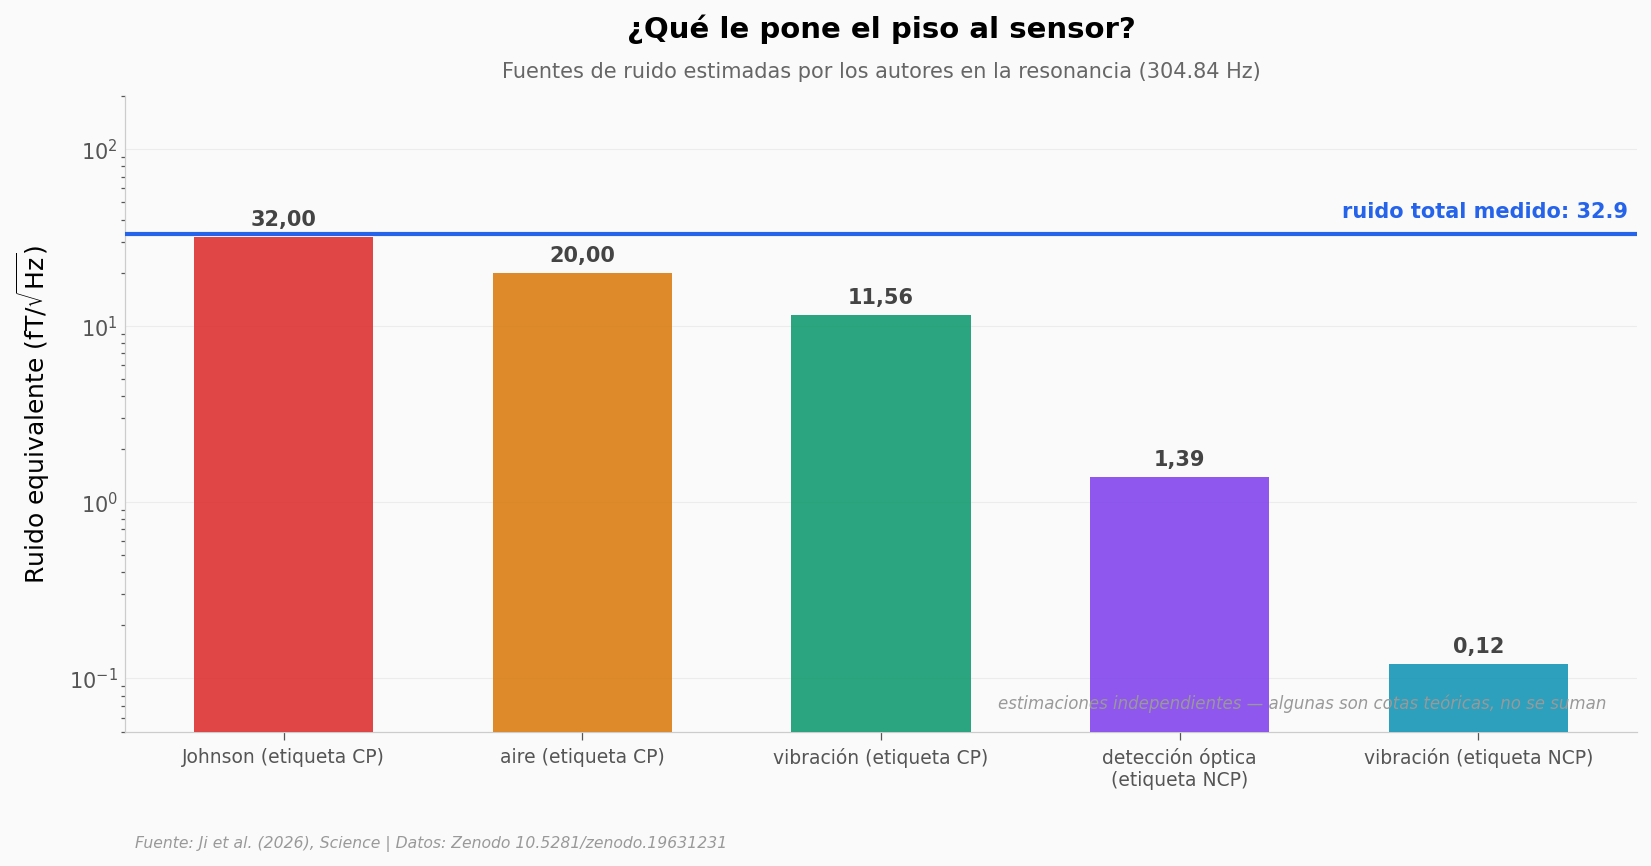

Suma en cuadratura de los componentes: 39,49 fT/√Hz
Ruido total medido:                    32,94 fT/√Hz
La suma SUPERA al total medido: son estimaciones independientes, no sumandos de un presupuesto cerrado.
Lo que sí se lee: la cota Johnson (32) queda pegada al total medido (32,9); la detección óptica (1,39) esta 24 veces más abajo.


In [4]:
fila = zoom.loc[i_min]
componentes = [
    ('Johnson (etiqueta CP)',   fila['ruido_cp_johnson_ft'],    COLOR_ALERTA),
    ('aire (etiqueta CP)',      fila['ruido_cp_aire_ft'],       COLOR_REFERENCIA),
    ('vibración (etiqueta CP)', fila['ruido_cp_vibracion_ft'],  COLOR_SECUNDARIO),
    ('detección óptica\n(etiqueta NCP)', fila['ruido_ncp_deteccion_ft'], '#7C3AED'),
    ('vibración (etiqueta NCP)', fila['ruido_ncp_vibracion_ft'], '#0891B2'),
]
etiquetas = [c[0] for c in componentes]
valores   = [c[1] for c in componentes]
colores   = [c[2] for c in componentes]

fig, ax = plt.subplots(figsize=(13, 5.5))
posiciones = np.arange(len(valores))
ax.bar(posiciones, valores, color=colores, alpha=0.85, width=0.6, zorder=3)
for p, v in zip(posiciones, valores):
    ax.text(p, v * 1.15, f'{v:.2f}'.replace('.', ','), ha='center',
            fontsize=10, fontweight='bold', color='#444444')

ax.axhline(y=SENS_MIN, color=COLOR_DATOS, linewidth=2.0, zorder=4)
ax.text(len(valores) - 0.5, SENS_MIN * 1.25, f'ruido total medido: {SENS_MIN:.1f}',
        fontsize=10, fontweight='bold', color=COLOR_DATOS, ha='right')

ax.set_yscale('log')
ax.set_ylim(0.05, 200)
ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_title('¿Qué le pone el piso al sensor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Fuentes de ruido estimadas por los autores en la resonancia ({FREQ_MIN:.2f} Hz)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Ruido equivalente (fT/$\\sqrt{\\mathrm{Hz}}$)')
ax.text(0.98, 0.03, 'estimaciones independientes — algunas son cotas teóricas, no se suman',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/presupuesto_ruido.png', dpi=200, bbox_inches='tight')
plt.show()

suma_cuadratura = np.sqrt(sum(v**2 for v in valores))
print(f'Suma en cuadratura de los componentes: {es(suma_cuadratura, 2)} fT/√Hz')
print(f'Ruido total medido:                    {es(SENS_MIN, 2)} fT/√Hz')
print('La suma SUPERA al total medido: son estimaciones independientes, no sumandos de un presupuesto cerrado.')
print(f'Lo que sí se lee: la cota Johnson ({es(fila["ruido_cp_johnson_ft"])}) queda pegada al total medido '
      f'({es(SENS_MIN, 1)}); la detección óptica ({es(fila["ruido_ncp_deteccion_ft"], 2)}) esta '
      f'{es(SENS_MIN / fila["ruido_ncp_deteccion_ft"])} veces más abajo.')

## ¿Qué tan excepcional es ese punto?

El láser no es el límite: lee 24 veces más fino que el mayor de los ruidos estimados. El candidato a mandar es el ruido Johnson —la agitación térmica de los electrones en los conductores cercanos—, cuya cota, 32 fT/√Hz, queda pegada al total medido. Cota, no medición: los autores la dejaron constante en todo el rango.

Falta ponerle tamaño al pozo. Si tomamos las 2.399 ventanas del espectro completo y las ordenamos por sensibilidad en vez de por frecuencia, ¿dónde cae el récord?

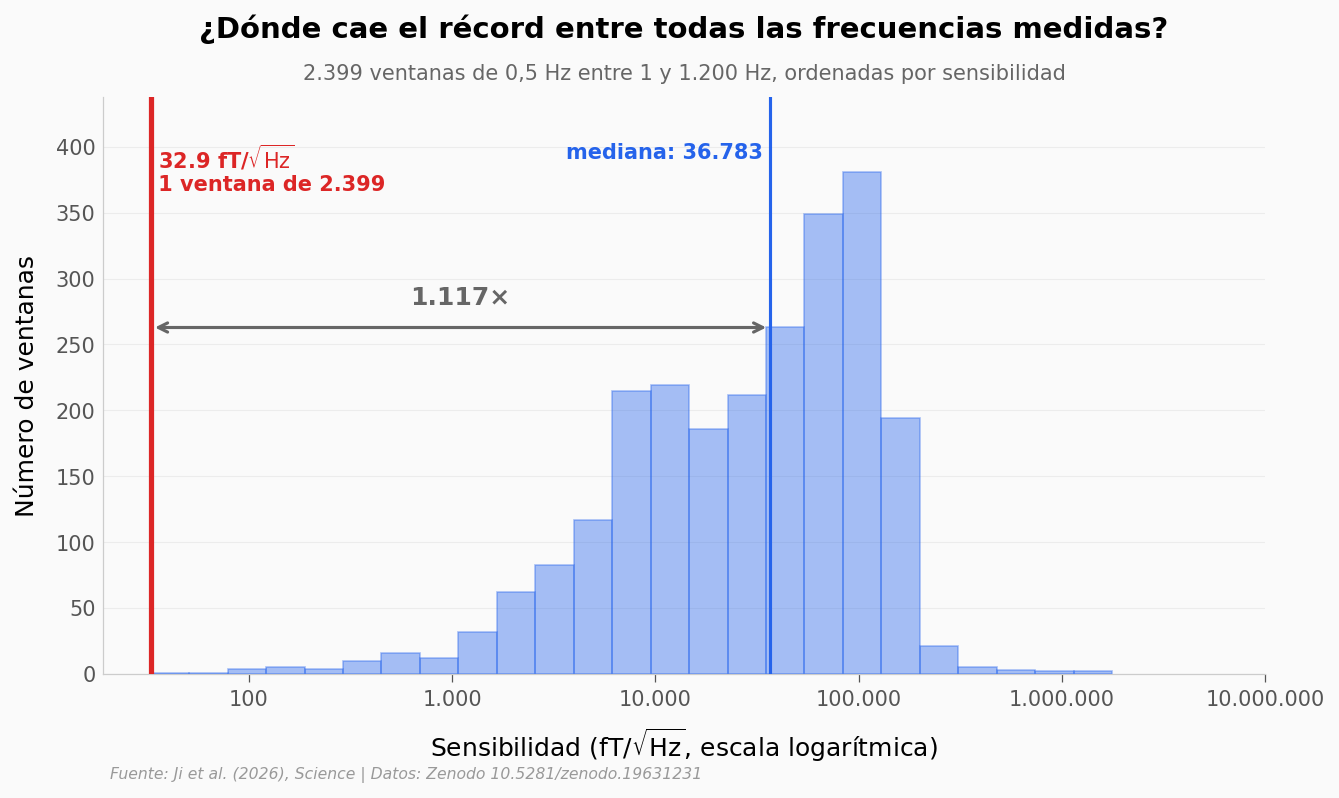

Mediana de las 2.399 ventanas: 36.783 fT/√Hz
Ventanas por debajo de 100 fT/√Hz: 5 de 2.399
El récord está 1.117 veces por debajo de la mediana.


In [5]:
valores_log = np.log10(banda['sensibilidad_min_ft'])
mediana_log = np.median(valores_log)
mediana_ft  = 10 ** mediana_log

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(valores_log, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8, zorder=3)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=mediana_log, color=COLOR_DATOS, linewidth=1.5, zorder=4)
ax.axvline(x=np.log10(SENS_MIN), color=COLOR_ALERTA, linewidth=2.5, zorder=5)
ax.annotate('', xy=(np.log10(SENS_MIN), y_max * 0.6), xytext=(mediana_log, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((np.log10(SENS_MIN) + mediana_log) / 2, y_max * 0.64,
        f'{mediana_ft/SENS_MIN:,.0f}'.replace(',', '.') + '×',
        ha='center', fontsize=12, fontweight='bold', color='#666666')

ax.text(np.log10(SENS_MIN), y_max * 0.92, f' {SENS_MIN:.1f} fT/$\\sqrt{{\\mathrm{{Hz}}}}$\n 1 ventana de 2.399',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, va='top')
ax.text(mediana_log, y_max * 0.92, f'mediana: {mediana_ft:,.0f} '.replace(',', '.'),
        fontsize=10, fontweight='bold', color=COLOR_DATOS, va='top', ha='right')

ticks = [2, 3, 4, 5, 6, 7]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{10**t:,.0f}'.replace(',', '.') for t in ticks])
ax.set_title('¿Dónde cae el récord entre todas las frecuencias medidas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '2.399 ventanas de 0,5 Hz entre 1 y 1.200 Hz, ordenadas por sensibilidad',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Sensibilidad (fT/$\\sqrt{\\mathrm{Hz}}$, escala logarítmica)')
ax.set_ylabel('Número de ventanas')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana de las {es(len(banda))} ventanas: {es(mediana_ft)} fT/√Hz')
print(f'Ventanas por debajo de 100 fT/√Hz: {(banda.sensibilidad_min_ft < 100).sum()} de {es(len(banda))}')
print(f'El récord está {es(mediana_ft/SENS_MIN)} veces por debajo de la mediana.')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Alcanzaron 32 fT/√Hz | ✅ | El mínimo del espectro depositado es 32,94 fT/√Hz a 304,84 Hz. La media de las 5 repeticiones ahí mismo es 30,3 ± 2,4, y el 32 del paper cae dentro de la banda. |
| Funciona a temperatura ambiente y bajo el campo terrestre | ⚠️ | Es la premisa del montaje y así lo declara el resumen del paper, pero no es verificable con estos archivos: ninguno de los cinco CSV trae temperatura ni campo de fondo, solo espectros de ruido. |
| Iguala a los SQUID y a los magnetómetros atómicos | ⚠️ | Solo **en su resonancia**. El pico contiguo alrededor del récord por debajo de 100 fT/√Hz mide 0,04 Hz (4 puntos de 0,01 Hz, entre 304,82 y 304,85 Hz) y un solo punto baja de 40 fT/√Hz. En todo el barrido fino hay 21 puntos bajo ese umbral, repartidos en 8 grupos separados. Los SQUID y los atómicos operan en banda ancha. |
| El sensor está limitado por ruido Johnson | ⚠️ | La cota Johnson (32,0 fT/√Hz) queda justo por debajo del total medido (32,94), y la detección óptica aporta 1,39 — 24 veces menos. Pero ese 32,0 es una constante en todo el archivo, no un espectro medido, y la suma en cuadratura de los componentes (39,49) ya supera al total: al menos una estimación está inflada. El dato es compatible con un piso Johnson; no lo confirma. |
| El presupuesto de ruido explica el total | ❌ | La suma en cuadratura de los cinco componentes da 39,49 fT/√Hz, **por encima** del total medido (32,94). Son estimaciones independientes y algunas son cotas teóricas, no un presupuesto que cierre. |
| Sirve para biología, química y física fundamental | ⚠️ | Es una proyección de los autores en el resumen del paper, no un resultado de este trabajo. No hay ninguna medición biológica ni química en los datos. |

> **Limitaciones:**
> - **Es un sensor resonante de banda estrecha.** A 1,25 Hz mide 471.559 fT/√Hz, 14.317 veces peor que en resonancia. El récord vive en un pico de 0,04 Hz de ancho.
> - **El factor de calidad Q no es calculable con estos datos.** El pico ocupa 1-2 puntos de 0,01 Hz: no está resuelto. Dividir la frecuencia entre un punto daría una cifra de cinco dígitos, pero sería un artefacto de la resolución del registro, no una medición. Lo único que se puede decir es que el pico es más estrecho que lo que el registro alcanza a resolver.
> - **Cinco repeticiones son pocas.** Los valores individuales en la resonancia van de 24,5 a 38,8 fT/√Hz. La banda del archivo es el error estándar de la media de las cinco (desviación muestral 5,43 / √5 = 2,43), no una desviación típica: un intervalo del 95% con n = 5 iría de 23,6 a 37,1 fT/√Hz.
> - **Dos de los componentes de ruido son constantes** en el archivo original (32,0 y 20,0 exactos en todo el rango), no espectros medidos punto a punto: son cotas estimadas.
> - **Los registros no son simultáneos.** El pico de la curva de respuesta cae cerca de 304,3 Hz y el mínimo del espectro de sensibilidad en 304,84 Hz. Son medidas distintas del mismo montaje, no el mismo barrido.
> - **Las etiquetas CP y NCP** vienen así en los datos originales. El paper está tras muro de pago y no hay preprint público, así que no expandimos los acrónimos: el grupo CP reúne ruidos físicos que actúan sobre el imán (Johnson, aire, vibración) y el grupo NCP incluye el ruido de la lectura óptica.

## Ahora tú

1. **¿Cuánto ancho de banda ganas si aceptas ser diez veces menos fino?** Cambia `UMBRAL_FT` a 330 en la celda de configuración y vuelve a correr — el conteo de puntos contiguos te dice cuánto se ensancha la franja útil.
2. **¿Se puede mover el pozo?** Los autores midieron la respuesta con dos campos guía distintos. La celda de abajo los grafica: si el pico se puede desplazar, un sensor de banda estrecha se vuelve un sensor *sintonizable*.
3. **¿Dónde está el segundo mejor punto del espectro completo?** Prueba con `banda.nsmallest(10, 'sensibilidad_min_ft')` y mira a qué frecuencias caen. ¿Son vecinas de la resonancia o hay otro pozo escondido?

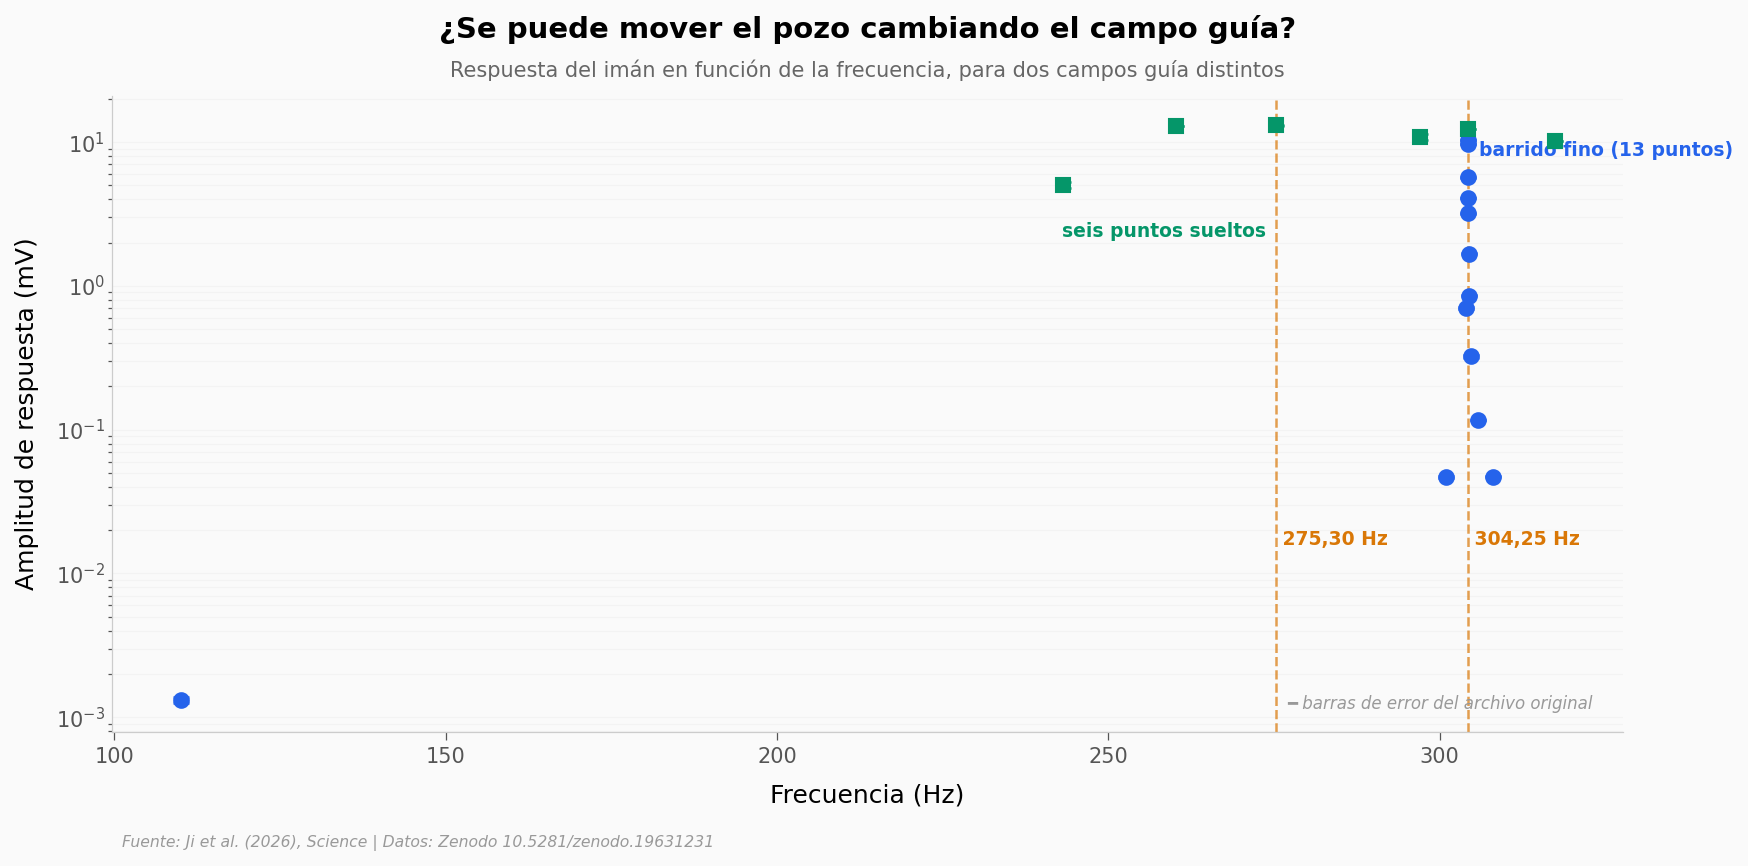

Barrido fino: pico en 304,27 Hz
Seis puntos: máximos locales muestreados en 275,30 y 304,25 Hz
El archivo no trae ninguna columna que diga a qué campo guía pertenece cada punto:
con seis puntos sueltos no se puede ajustar una curva de resonancia ni atribuir cada pico a su campo.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Se puede mover la resonancia cambiando el campo guía?

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.errorbar(respuesta['frecuencia_hz'], respuesta['amplitud_v'] * 1000,
            yerr=respuesta['error_v'] * 1000, fmt='o', color=COLOR_DATOS,
            markersize=7, capsize=4, capthick=1.2, linewidth=1.2, zorder=5)
ax.errorbar(campo_guia['frecuencia_hz'], campo_guia['amplitud_v'] * 1000,
            yerr=campo_guia['error_v'] * 1000, fmt='s', color=COLOR_SECUNDARIO,
            markersize=7, capsize=4, capthick=1.2, linewidth=0, zorder=5)

ax.set_yscale('log')
_cg = campo_guia.sort_values('frecuencia_hz').reset_index(drop=True)
MAX_LOCALES = [_cg.frecuencia_hz[k] for k in range(1, len(_cg) - 1)
               if _cg.amplitud_v[k] > _cg.amplitud_v[k - 1] and _cg.amplitud_v[k] > _cg.amplitud_v[k + 1]]
for _f in MAX_LOCALES:
    ax.axvline(x=_f, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.7, zorder=2)
    ax.text(_f, 0.02, f' {es(_f, 2)} Hz', fontsize=9,
            color=COLOR_REFERENCIA, fontweight='bold', va='top')

ax.text(306, 8, 'barrido fino (13 puntos)', fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(243, 2.2, 'seis puntos sueltos', fontsize=9,
        color=COLOR_SECUNDARIO, fontweight='bold')
ax.text(0.98, 0.03, '━ barras de error del archivo original', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax.set_title('¿Se puede mover el pozo cambiando el campo guía?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Respuesta del imán en función de la frecuencia, para dos campos guía distintos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Amplitud de respuesta (mV)')
ax.grid(True, which='both', axis='y', alpha=0.25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/campo_guia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Barrido fino: pico en {es(respuesta.loc[respuesta.amplitud_v.idxmax(), "frecuencia_hz"], 2)} Hz')
print('Seis puntos: máximos locales muestreados en ' + ' y '.join(es(x, 2) for x in MAX_LOCALES) + ' Hz')
print('El archivo no trae ninguna columna que diga a qué campo guía pertenece cada punto:')
print('con seis puntos sueltos no se puede ajustar una curva de resonancia ni atribuir cada pico a su campo.')

---

## Fuentes

**Paper**: [Levitated sensor for magnetometry in ambient environment](https://doi.org/10.1126/science.adx1707)  
*Science, 2026-08-06 · paywall*

**Dataset canónico**: [Levitated Sensor for Magnetometry in Ambient Environment (código MATLAB y datos)](https://doi.org/10.5281/zenodo.19631231)  
*Código MATLAB y datos crudos de las figuras 2, 3 y 4 (CC-BY-4.0)*

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)*